In [44]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings('ignore')


In [45]:
df = pd.read_csv('heart.csv')
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [46]:
df.columns
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

<Axes: xlabel='HeartDisease'>

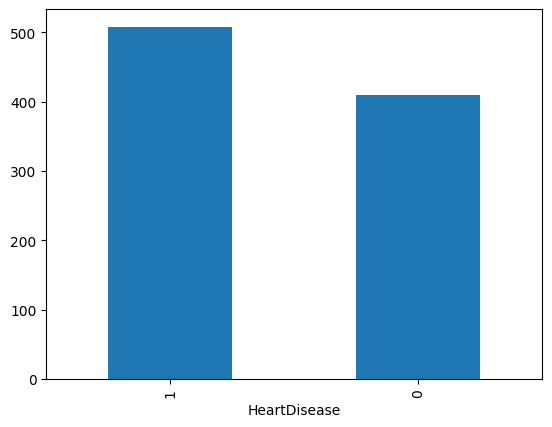

In [47]:
df['HeartDisease'].value_counts().plot(kind = "bar")
# df['ChestPainType'].value_counts().plot(kind = "bar")

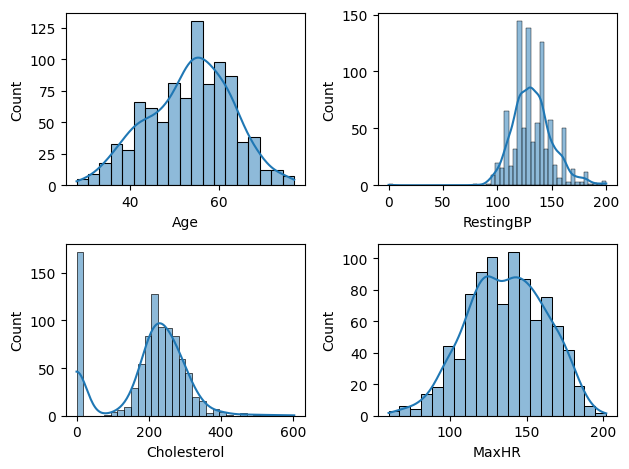

In [48]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde = True)

plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)
 
plt.tight_layout()

In [49]:
df["Cholesterol"].value_counts()
ch_mean = df.loc[df['Cholesterol'] != 0,'Cholesterol'].mean()
df['Cholesterol'] = df['Cholesterol'].replace(0,ch_mean)
df['Cholesterol'] = df['Cholesterol'].round(2)

RestingBP_mean = df.loc[df['RestingBP']!= 0,'RestingBP'].mean()
df['RestingBP'] = df['RestingBP'].replace(0,RestingBP_mean)
df['RestingBP'] = df['RestingBP'].round(2)


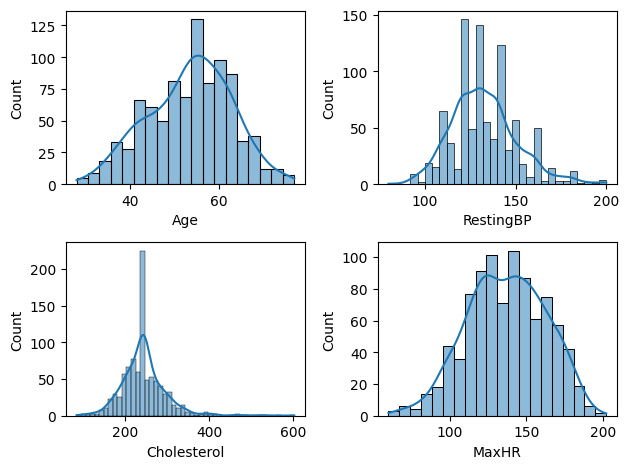

In [50]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde = True)

plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)


plt.tight_layout()

<Axes: xlabel='Sex', ylabel='count'>

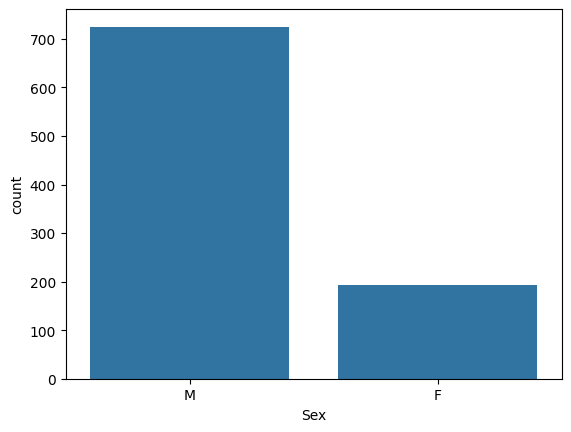

In [51]:
sns.countplot(x = df['Sex'])

<Axes: xlabel='ChestPainType', ylabel='count'>

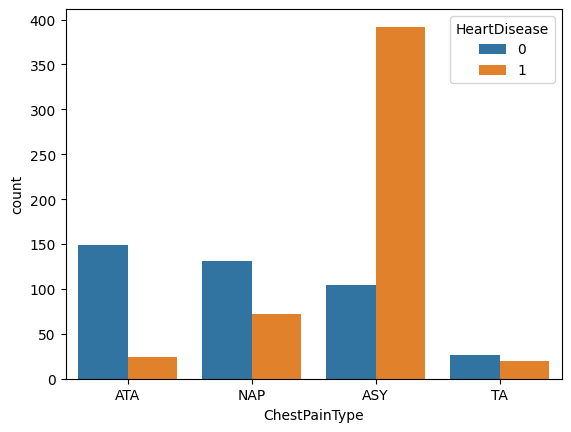

In [52]:
sns.countplot(x = df['ChestPainType'],hue= df['HeartDisease'])

<Axes: xlabel='Age', ylabel='MaxHR'>

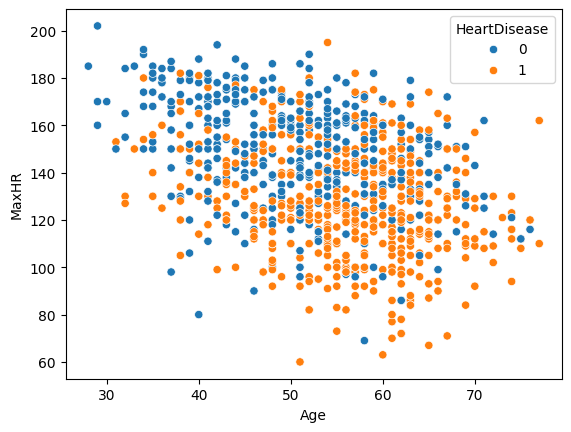

In [53]:
sns.scatterplot(x= 'Age',
                y= 'MaxHR',
                hue='HeartDisease',
                data = df)


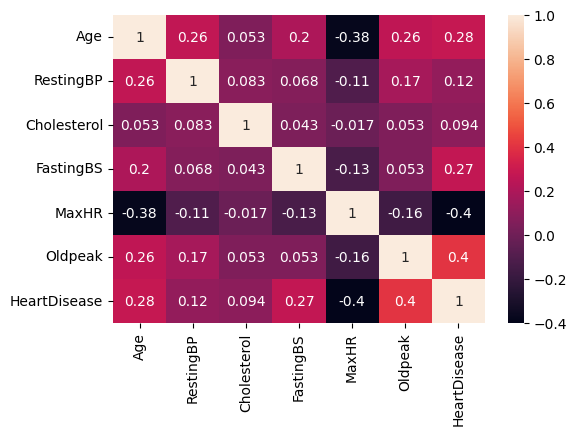

In [54]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

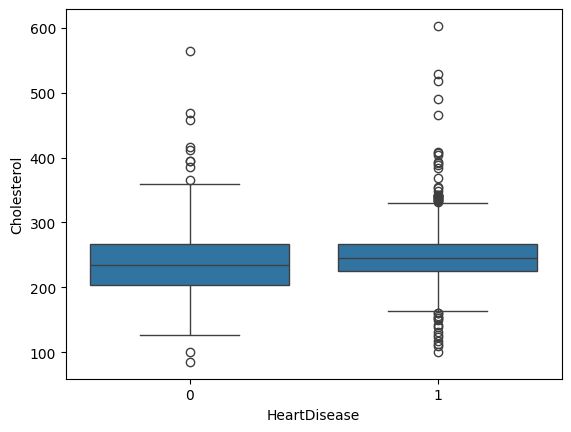

In [55]:
sns.boxplot(x= 'HeartDisease',y= 'Cholesterol',data = df)

<Axes: xlabel='HeartDisease', ylabel='Age'>

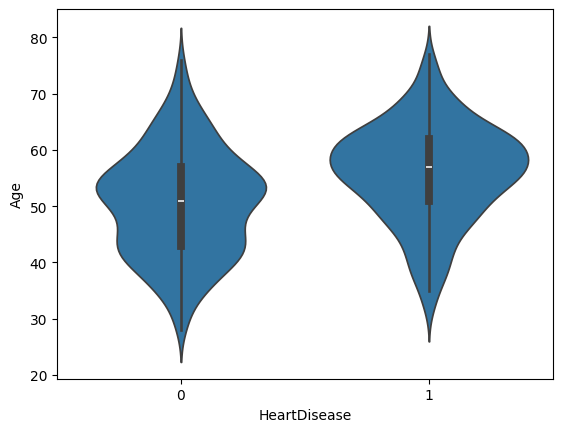

In [56]:
sns.violinplot(x='HeartDisease', y='Age', data=df)

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

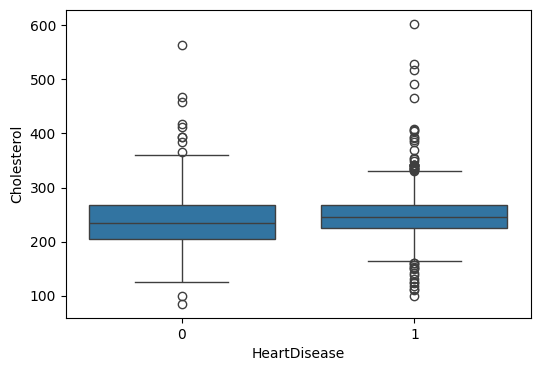

In [57]:
plt.figure(figsize= (6,4))
sns.boxplot(x = 'HeartDisease', y = 'Cholesterol',data = df)

Data preprocessing

In [58]:
#column was containing the multiple category value it was make the separarte column for that category 
df_encode = pd.get_dummies(df,drop_first=True) 
df_encode
df_encode = df_encode.astype(int)
df_encode


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [59]:
#for making the data into -1 to 1 range bcoz the model wants pricies data
# from sklearn.preprocessing import StandardScaler
# numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
# scaler = StandardScaler()
# df_encode[numerical_cols] = scaler.fit_transform(df_encode[numerical_cols])
# df_encode.head()


In [60]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,f1_score,accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier 
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier            
from sklearn.preprocessing import StandardScaler

In [61]:
x = df_encode.drop('HeartDisease',axis = 1)
y = df_encode['HeartDisease']

xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size = 0.2,random_state = 42)


In [62]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(xtrain)
x_test_scaled = scaler.fit_transform(xtest)

In [63]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(),
    'SVM': SVC(),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

In [64]:
results = {}

In [ ]:
# Check each model one by one
for name, model in models.items():
    model.fit(x_train_scaled, ytrain)
    y_pred = model.predict(x_test_scaled)
    accuracy = accuracy_score(ytest, y_pred)
    f1 = f1_score(ytest, y_pred)

    results[name] = {'Accuracy': accuracy, 'F1 Score': f1}
results

{'Logistic Regression': {'Accuracy': 0.8695652173913043,
  'F1 Score': 0.8857142857142857},
 'Naive Bayes': {'Accuracy': 0.8532608695652174,
  'F1 Score': 0.8682926829268293},
 'Decision Tree': {'Accuracy': 0.7663043478260869,
  'F1 Score': 0.7881773399014779},
 'SVM': {'Accuracy': 0.8478260869565217, 'F1 Score': 0.8679245283018868},
 'K-Nearest Neighbors': {'Accuracy': 0.8641304347826086,
  'F1 Score': 0.8815165876777251}}

In [77]:
import pickle

pickle.dump(model, open("heartdisease_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(xtrain.columns.tolist(), open("expected_columns.pkl", "wb"))